In [ ]:
import sklearn
print("CRITICAL VERSION NUMBER:", sklearn.__version__)

CRITICAL VERSION NUMBER: 1.6.1


CRITICAL VERSION NUMBER: 1.6.1, Environment: Scikit-Learn Version for Phase 2

LOOK INTO THE DATASTRUCTURE

In [ ]:
import pandas as pd

# Paste your copied path between the quotes below
data_path = '/content/drive/MyDrive/Cardio_Risk_Project/heart.csv'

df = pd.read_csv(data_path)

# Let's see if the data looks healthy
print(f"Dataset Loaded: {df.shape[0]} patients and {df.shape[1]} clinical features.")
df.head()

Dataset Loaded: 918 patients and 12 clinical features.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Create a list of your text-based columns
categorical_columns = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# Loop through and print the value counts for each one
for col in categorical_columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Sex ---
Sex
M    725
F    193
Name: count, dtype: int64


--- ChestPainType ---
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


--- RestingECG ---
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


--- ExerciseAngina ---
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


--- ST_Slope ---
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64




In [ ]:
# Show the statistical summary of all numerical columns
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


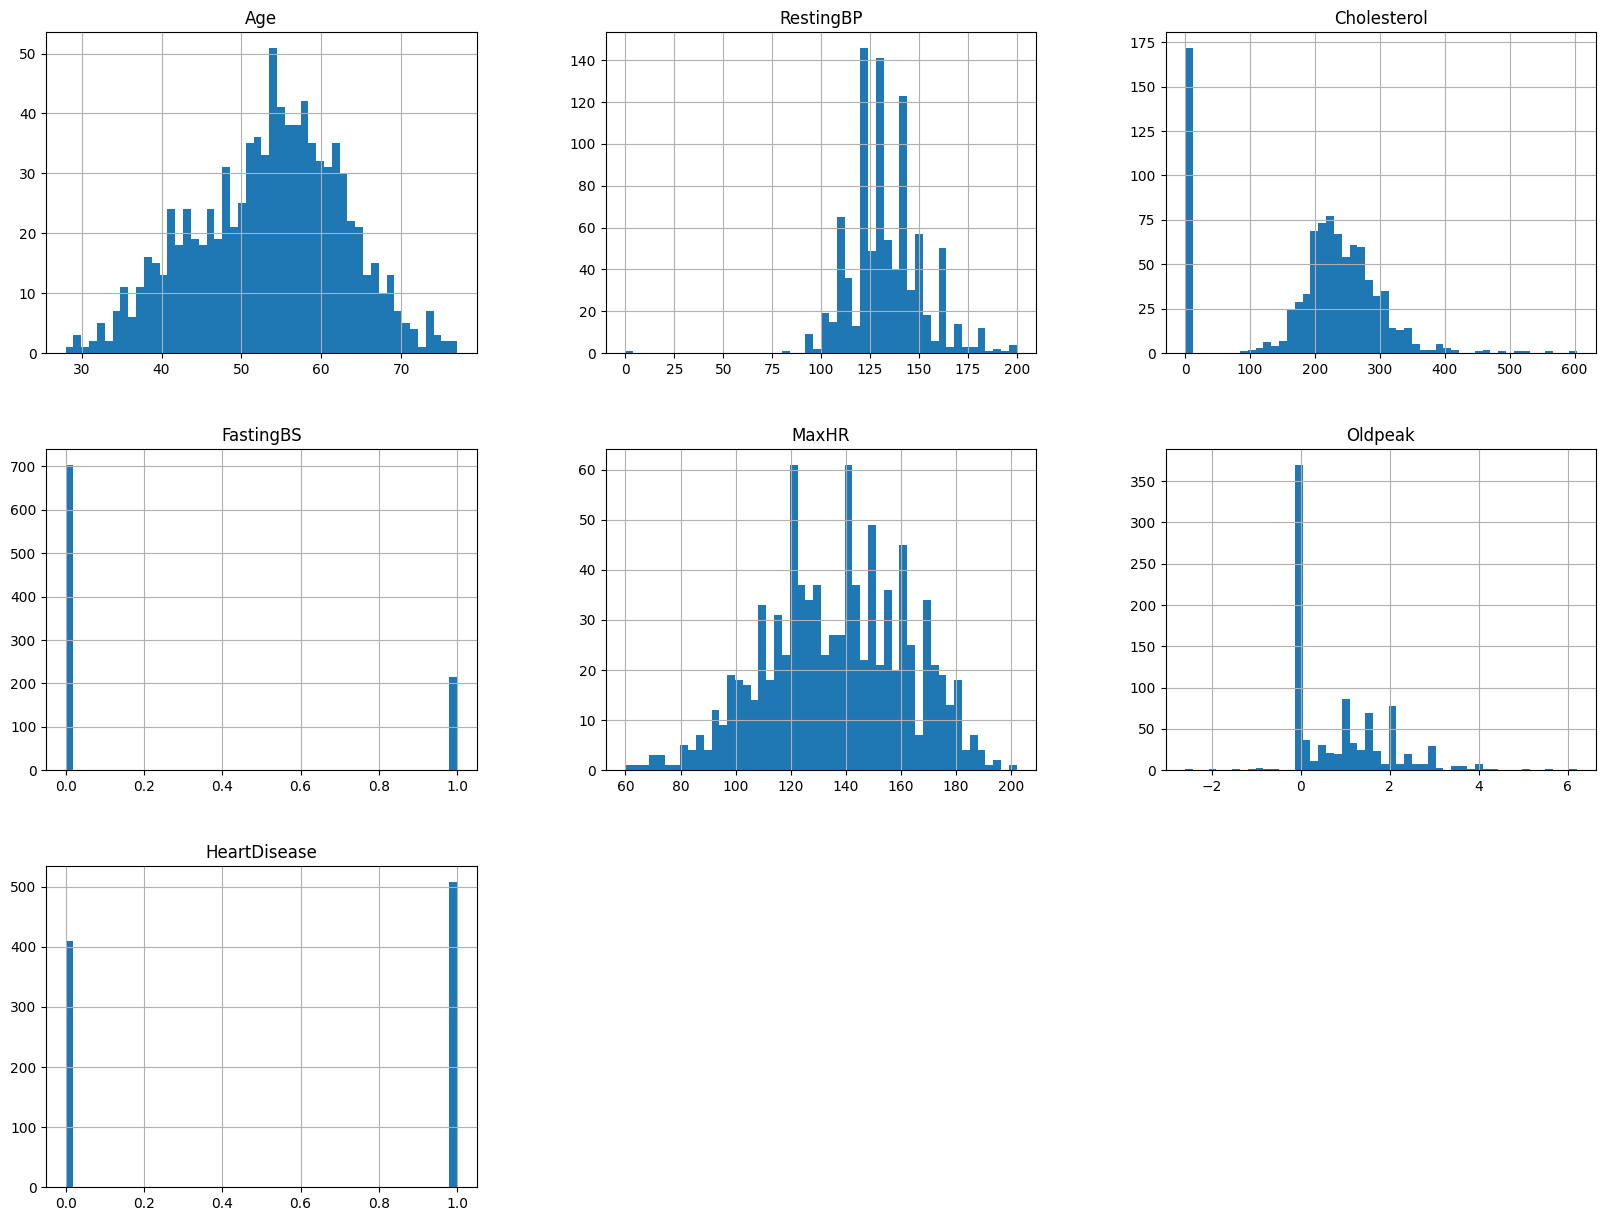

In [ ]:
import matplotlib.pyplot as plt

# The 'bins=50' cuts the data into 50 slender columns
# 'figsize' makes the picture big enough to read easily
df.hist(bins=50, figsize=(20,15))
plt.show()

CREATING A TEST SET

In [ ]:
import pandas as pd

# Point to the dataset in your mounted Drive
path = "/content/drive/MyDrive/Cardio_Risk_Project/heart.csv"

# Read the file and store it in the variable named 'df'
df = pd.read_csv(path)

print("Data loaded successfully! Now Python knows what 'df' is.")

Data loaded successfully! Now Python knows what 'df' is.


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Stratified Split Successful!")

✅ Stratified Split Successful!


In [ ]:
import pandas as pd

# 1. Calculate the proportions for all three groups
overall_proportions = y.value_counts(normalize=True)
train_proportions = y_train.value_counts(normalize=True)
test_proportions = y_test.value_counts(normalize=True)

# 2. Combine them into a single, clean Pandas DataFrame for easy comparison
comparison_table = pd.DataFrame({
    "Overall Data": overall_proportions,
    "Stratified Train Set": train_proportions,
    "Stratified Test Set": test_proportions
})

# 3. Print the results (multiply by 100 to show as percentages)
print(comparison_table * 100)

              Overall Data  Stratified Train Set  Stratified Test Set
HeartDisease                                                         
1                55.337691             55.313351            55.434783
0                44.662309             44.686649            44.565217


In [ ]:
# 1. Start with a copy of your training features
heart_exploration = X_train.copy()

# 2. Add the target answers back into this sandbox
heart_exploration["HeartDisease"] = y_train

print("✅ Exploration sandbox created successfully!")

✅ Exploration sandbox created successfully!


looking for correlations

In [ ]:
# Calculate the correlations (only using numbers)
corr_matrix = heart_exploration.corr(numeric_only=True)

# Look at the correlations specifically for HeartDisease, sorted highest to lowest
print("--- Correlation with Heart Disease ---")
print(corr_matrix["HeartDisease"].sort_values(ascending=False))

--- Correlation with Heart Disease ---
HeartDisease    1.000000
Oldpeak         0.376603
FastingBS       0.261391
Age             0.244689
RestingBP       0.102055
Cholesterol    -0.241413
MaxHR          -0.407227
Name: HeartDisease, dtype: float64


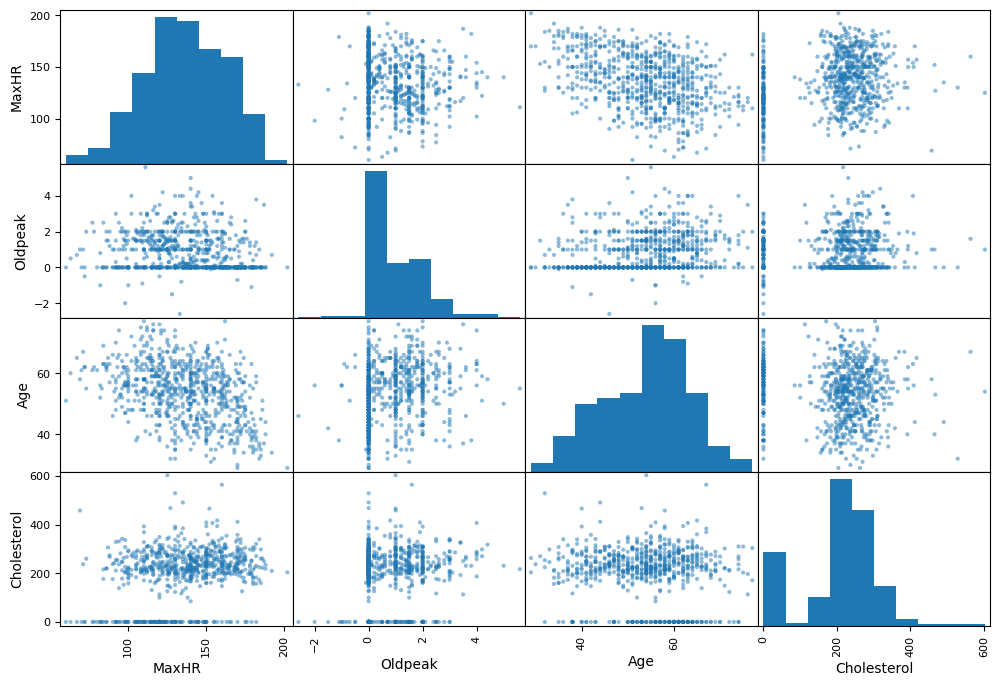

In [ ]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# We pick the top numerical features we found in the correlation step
attributes = ["MaxHR", "Oldpeak", "Age", "Cholesterol"]

# Plot the matrix! (figsize makes it big enough to read)
scatter_matrix(heart_exploration[attributes], figsize=(12, 8))
plt.show()

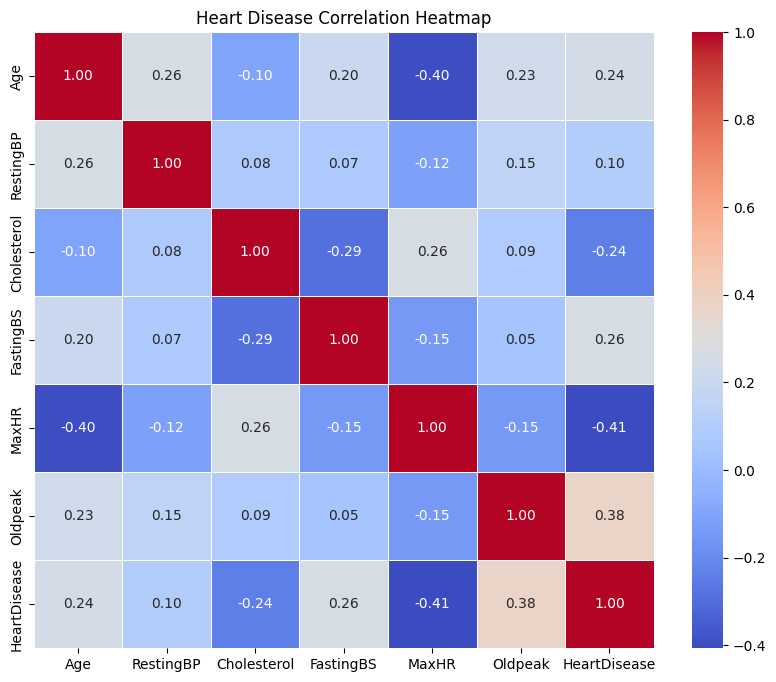

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the size of the graph
plt.figure(figsize=(10, 8))

# Create the heatmap using our corr_matrix from earlier
# annot=True puts the actual numbers inside the colored boxes
# cmap="coolwarm" uses blue for negative (protective) and red for positive (danger)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Heart Disease Correlation Heatmap")
plt.show()

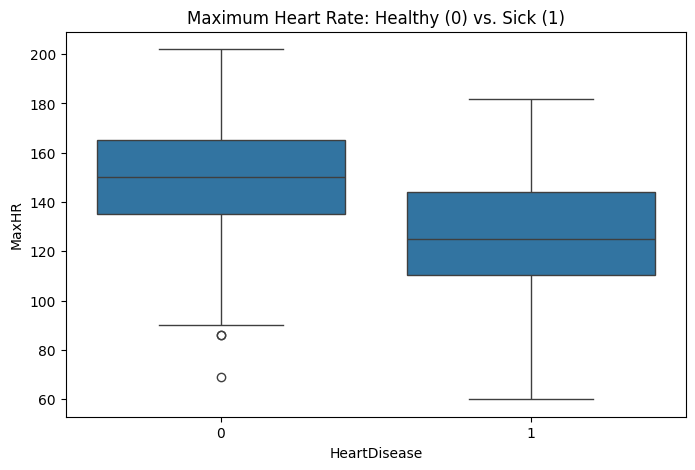

In [ ]:
plt.figure(figsize=(8, 5))

# We plot HeartDisease on the X axis, and MaxHR on the Y axis
sns.boxplot(x="HeartDisease", y="MaxHR", data=heart_exploration)

plt.title("Maximum Heart Rate: Healthy (0) vs. Sick (1)")
plt.show()

Experiment with Attribute Combinations

In [ ]:
# 1. Create the new "Super Symptoms"
heart_exploration["Rate_Pressure_Product"] = heart_exploration["RestingBP"] * heart_exploration["MaxHR"]
heart_exploration["HR_per_Age"] = heart_exploration["MaxHR"] / heart_exploration["Age"]

# 2. Re-calculate the Correlation Matrix with the new features included
corr_matrix = heart_exploration.corr(numeric_only=True)

# 3. Print the results to see if our new features beat the old ones
print("--- Updated Correlations with Heart Disease ---")
print(corr_matrix["HeartDisease"].sort_values(ascending=False))

--- Updated Correlations with Heart Disease ---
HeartDisease             1.000000
Oldpeak                  0.376603
FastingBS                0.261391
Age                      0.244689
RestingBP                0.102055
Cholesterol             -0.241413
Rate_Pressure_Product   -0.292546
HR_per_Age              -0.378148
MaxHR                   -0.407227
Name: HeartDisease, dtype: float64


Data cleaning

simple imputer

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# 1. Step One: Turn the "Lies" into "NaNs"
# We only do this for Cholesterol and RestingBP where 0 is impossible
X_train_prepped = X_train.copy()
X_train_prepped[["Cholesterol", "RestingBP"]] = X_train_prepped[["Cholesterol", "RestingBP"]].replace(0, np.nan)

# 2. Step Two: Create the Imputer (The 'Median' strategy is safest)
imputer = SimpleImputer(strategy="median")

# 3. Step Three: The Imputer only works on numbers
# Create a copy of the data with only the numerical attributes
X_train_num = X_train_prepped.select_dtypes(include=[np.number])

# 4. Step Four: Fit and Transform
# 'Fit' calculates the medians, 'Transform' fills the holes
X_num_cleaned = imputer.fit_transform(X_train_num)

# 5. Step Five: Put it back into a DataFrame
# (SimpleImputer returns a Numpy array, so we wrap it back in a DataFrame)
X_train_num_final = pd.DataFrame(X_num_cleaned, columns=X_train_num.columns, index=X_train.index)

print("✅ Data Cleaning Complete!")
print(f"Missing values left in Cholesterol: {X_train_num_final['Cholesterol'].isnull().sum()}")

✅ Data Cleaning Complete!
Missing values left in Cholesterol: 0


In [ ]:
# 1. See what the imputer 'learned'
print("--- Imputer Statistics (The Learned Medians) ---")
print(imputer.statistics_)

# 2. Check it manually using Pandas
print("\n--- Manual Medians from Pandas ---")
print(X_train_num.median().values)

# 3. Double-check the column names to be sure which is which
print("\n--- Column Order ---")
print(list(X_train_num.columns))

--- Imputer Statistics (The Learned Medians) ---
[ 55.  130.  238.    0.  138.    0.5]

--- Manual Medians from Pandas ---
[ 55.  130.  238.    0.  138.    0.5]

--- Column Order ---
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [ ]:
# 1. Transform the data (This creates a NumPy array)
X_train_num_transformed = imputer.transform(X_train_num)

# 2. Check the feature names the imputer 'remembered'
print("Features processed:", imputer.feature_names_in_)

# 3. Convert back to a DataFrame so we can use Pandas again
X_train_num_tr = pd.DataFrame(
    X_train_num_transformed,
    columns=X_train_num.columns,
    index=X_train_num.index
)

# 4. Verification: Let's find a row that used to have a 0 for Cholesterol
# In the original heart.csv, row index 293 (for example) often has a 0
# We check if it is now filled with the median
print("\n--- Verification of Imputed Values ---")
print(X_train_num_tr.head())

Features processed: ['Age' 'RestingBP' 'Cholesterol' 'FastingBS' 'MaxHR' 'Oldpeak']

--- Verification of Imputed Values ---
      Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak
485  63.0      139.0        217.0        1.0  128.0      1.2
486  55.0      110.0        214.0        1.0  180.0      0.4
117  59.0      130.0        338.0        1.0  130.0      1.5
361  47.0      160.0        238.0        0.0  124.0      0.0
296  50.0      145.0        238.0        1.0  139.0      0.7


Handling Text and Categorical Attributes

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Identify your categorical columns
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# 2. Create the encoder with the "Geron Settings"
# handle_unknown='ignore' ensures we don't crash on new data later
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 3. Fit and transform the categorical data
X_train_cat_1hot = cat_encoder.fit_transform(X_train[cat_cols])

# 4. Turn it back into a clean DataFrame with the correct column names
X_train_cat_final = pd.DataFrame(
    X_train_cat_1hot,
    columns=cat_encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

print("✅ Categorical Encoding Complete!")
print(f"Original columns: {len(cat_cols)}")
print(f"New One-Hot columns: {X_train_cat_final.shape[1]}")
X_train_cat_final.head()

✅ Categorical Encoding Complete!
Original columns: 5
New One-Hot columns: 14


,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
486,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
117,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
361,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
296,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


Feature Scaling and Transformation

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Initialize the scaler, just like Geron does
std_scaler = StandardScaler()

# 2. Fit and transform your clean numerical data (the data without zeros)
X_train_scaled_array = std_scaler.fit_transform(X_train_num_tr)

# 3. The scaler spits out a raw NumPy array, so we wrap it back in a Pandas DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train_num_tr.columns,
    index=X_train_num_tr.index
)

# 4. Let's visually compare the BEFORE and AFTER!
print("--- BEFORE SCALING (RestingBP) ---")
print(X_train_num_tr["RestingBP"].head())

print("\n--- AFTER SCALING (RestingBP) ---")
print(X_train_scaled["RestingBP"].head())

--- BEFORE SCALING (RestingBP) ---
485    139.0
486    110.0
117    130.0
361    160.0
296    145.0
Name: RestingBP, dtype: float64

--- AFTER SCALING (RestingBP) ---
485    0.339016
486   -1.266031
117   -0.159102
361    1.501291
296    0.671094
Name: RestingBP, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Separate your column names into Numbers and Text
num_attribs = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
cat_attribs = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# 2. Build the Numerical Pipeline (Impute the zeros, THEN scale the numbers)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])

# 3. Build the Master ColumnTransformer
# This sends the numbers to the num_pipeline, and the text to the OneHotEncoder!
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
])

# 4. PRE-STEP: Fix those dangerous "0"s in Cholesterol and BP before they enter the pipeline
X_train_prepped = X_train.copy()
X_train_prepped[["Cholesterol", "RestingBP"]] = X_train_prepped[["Cholesterol", "RestingBP"]].replace(0, np.nan)

# 5. THE MAGIC BUTTON: Run the whole factory on your data!
X_train_prepared = full_pipeline.fit_transform(X_train_prepped)

print("✅ Master Pipeline Complete!")
print(f"Final shape of your data: {X_train_prepared.shape}")

✅ Master Pipeline Complete!
Final shape of your data: (734, 20)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Initialize the Model (The "Doctor")
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. THE BIG MOMENT: Train the model!
log_reg.fit(X_train_prepared, y_train)

# 3. Ask the model to predict the diagnosis for the exact patients it just studied
predictions = log_reg.predict(X_train_prepared)

# 4. Compare the model's predictions to the actual truth (y_train)
accuracy = accuracy_score(y_train, predictions)

print("✅ Model Successfully Trained!")
print(f"🎯 Accuracy on Training Data: {accuracy * 100:.2f}%")

# Let's look at the first 5 predictions vs reality:
print("\n--- Quick Sanity Check (First 5 Patients) ---")
print(f"Model Predictions: {predictions[:5]}")
print(f"Actual Diagnoses:  {y_train.iloc[:5].values}")

✅ Model Successfully Trained!
🎯 Accuracy on Training Data: 85.83%

--- Quick Sanity Check (First 5 Patients) ---
Model Predictions: [1 0 1 1 1]
Actual Diagnoses:  [1 0 1 1 1]


In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Run the 10-Fold Cross Validation
# cv=10 means "give the model 10 separate pop quizzes"
scores = cross_val_score(log_reg, X_train_prepared, y_train, scoring="accuracy", cv=10)

# 2. Display the results
print("📊 --- CROSS VALIDATION RESULTS --- 📊")
print(f"All 10 Pop Quiz Scores: \n{np.round(scores * 100, 2)}")
print(f"\n🎯 TRUE AVERAGE ACCURACY: {scores.mean() * 100:.2f}%")
print(f"⚖️ Standard Deviation (+/-): {scores.std() * 100:.2f}%")

📊 --- CROSS VALIDATION RESULTS --- 📊
All 10 Pop Quiz Scores: 
[89.19 89.19 83.78 87.84 87.67 82.19 84.93 86.3  80.82 79.45]

🎯 TRUE AVERAGE ACCURACY: 85.14%
⚖️ Standard Deviation (+/-): 3.31%


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the "Board of Doctors"
# n_estimators=100 means we are using 100 'trees' (doctors) to vote
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Give the Random Forest the same 10 Pop Quizzes!
forest_scores = cross_val_score(forest_clf, X_train_prepared, y_train, scoring="accuracy", cv=10)

print("🌲 --- RANDOM FOREST RESULTS --- 🌲")
print(f"🎯 TRUE AVERAGE ACCURACY: {forest_scores.mean() * 100:.2f}%")
print(f"⚖️ Standard Deviation: {forest_scores.std() * 100:.2f}%")

🌲 --- RANDOM FOREST RESULTS --- 🌲
🎯 TRUE AVERAGE ACCURACY: 84.87%
⚖️ Standard Deviation: 3.56%


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Tell the Grid Search which "dials" to turn
# n_estimators = How many doctors in the forest?
# max_depth = How many questions can they ask? (Limits overthinking)
param_grid = [
    {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]},
]

# 2. Initialize the Robot Assistant
forest_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    forest_clf,
    param_grid,
    cv=5, # Give it 5 pop quizzes per combination
    scoring='accuracy',
    return_train_score=True
)

# 3. THE BIG SEARCH: Let it test every combination!
# (This might take 10-20 seconds depending on your computer)
grid_search.fit(X_train_prepared, y_train)

print("🔍 GRID SEARCH COMPLETE!")
print(f"🏆 Best Settings Found: {grid_search.best_params_}")
print(f"🎯 Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

🔍 GRID SEARCH COMPLETE!
🏆 Best Settings Found: {'max_depth': 5, 'n_estimators': 200}
🎯 Best Cross-Validation Accuracy: 86.24%


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Grab the absolute best model from your Grid Search
final_model = grid_search.best_estimator_

# 2. Fix the zeros in the Test Data (Just like we did for the Training Data)
X_test_prepped = X_test.copy()
X_test_prepped[["Cholesterol", "RestingBP"]] = X_test_prepped[["Cholesterol", "RestingBP"]].replace(0, np.nan)

# 3. CRITICAL: Pass the test data through the pipeline using ONLY .transform()
X_test_prepared = full_pipeline.transform(X_test_prepped)

# 4. Make the final medical diagnoses on the brand new patients
final_predictions = final_model.predict(X_test_prepared)

# 5. Grade the final exam!
final_accuracy = accuracy_score(y_test, final_predictions)

print("🚀 --- FINAL HOSPITAL DEPLOYMENT TEST --- 🚀")
print(f"Final Real-World Accuracy: {final_accuracy * 100:.2f}%")

🚀 --- FINAL HOSPITAL DEPLOYMENT TEST --- 🚀
Final Real-World Accuracy: 87.50%


In [ ]:
import joblib

# 1. Save your winning AI Doctor
joblib.dump(final_model, "heart_disease_model.pkl")

# 2. Save your Data Preparation Factory
joblib.dump(full_pipeline, "heart_data_pipeline.pkl")

print("💾 System permanently saved to disk!")

💾 System permanently saved to disk!


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# 1. Get the model's 'clean' predictions using Cross-Validation
# We are using your winning Random Forest from the Grid Search
y_train_pred = cross_val_predict(grid_search.best_estimator_, X_train_prepared, y_train, cv=5)

# 2. Build the Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)

print("🧮 --- CONFUSION MATRIX --- 🧮")
print("                 Predicted Healthy    Predicted Sick")
print(f"Actual Healthy |        {cm[0][0]} (TN)          {cm[0][1]} (FP)")
print(f"Actual Sick    |        {cm[1][0]} (FN)          {cm[1][1]} (TP)")

# 3. Calculate Precision and Recall
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)

print("\n📊 --- MEDICAL METRICS --- 📊")
print(f"🎯 Precision: {precision * 100:.2f}% (When it claims a patient is sick, how often is it right?)")
print(f"⚕️ Recall:    {recall * 100:.2f}% (Out of ALL the truly sick patients, how many did it catch?)")

🧮 --- CONFUSION MATRIX --- 🧮
                 Predicted Healthy    Predicted Sick
Actual Healthy |        267 (TN)          61 (FP)
Actual Sick    |        40 (FN)          366 (TP)

📊 --- MEDICAL METRICS --- 📊
🎯 Precision: 85.71% (When it claims a patient is sick, how often is it right?)
⚕️ Recall:    90.15% (Out of ALL the truly sick patients, how many did it catch?)


In [ ]:
# 1. Ask the AI for its exact confidence percentages instead of a hard Yes/No
# (Since we are using Random Forest, we use predict_proba)
y_probas = cross_val_predict(grid_search.best_estimator_, X_train_prepared, y_train, cv=5, method="predict_proba")

# 2. Extract the probabilities specifically for the "Sick" class (Column 1)
y_scores = y_probas[:, 1]

# 3. CREATE A CUSTOM MEDICAL THRESHOLD!
# Instead of 0.50 (50%), let's flag anyone who is even 30% at risk!
cautious_threshold = 0.30
y_cautious_predictions = (y_scores >= cautious_threshold).astype(int)

# 4. Generate the NEW Confusion Matrix and Metrics
new_cm = confusion_matrix(y_train, y_cautious_predictions)
new_precision = precision_score(y_train, y_cautious_predictions)
new_recall = recall_score(y_train, y_cautious_predictions)

print("🚨 --- CAUTIOUS AI METRICS (30% Threshold) --- 🚨")
print("                 Predicted Healthy    Predicted Sick")
print(f"Actual Healthy |        {new_cm[0][0]} (TN)          {new_cm[0][1]} (FP)")
print(f"Actual Sick    |        {new_cm[1][0]} (FN)          {new_cm[1][1]} (TP)")
print(f"\n🎯 New Precision: {new_precision * 100:.2f}%")
print(f"⚕️ New Recall:    {new_recall * 100:.2f}%")

🚨 --- CAUTIOUS AI METRICS (30% Threshold) --- 🚨
                 Predicted Healthy    Predicted Sick
Actual Healthy |        234 (TN)          94 (FP)
Actual Sick    |        17 (FN)          389 (TP)

🎯 New Precision: 80.54%
⚕️ New Recall:    95.81%
